In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model10_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model10_0)
describe(model10_0)

MACs: 5.45 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model10_0.pt
Starting
Epoch 1/60: Train loss = 1.0530, Train accuracy = 0.6233, Test loss = 1.0523, Test accuracy = 0.6283
Epoch 2/60: Train loss = 0.8493, Train accuracy = 0.6983, Test loss = 0.8302, Test accuracy = 0.7065
Epoch 3/60: Train loss = 0.7803, Train accuracy = 0.7241, Test loss = 0.7744, Test accuracy = 0.7284
Epoch 4/60: Train loss = 0.7312, Train accuracy = 0.7486, Test loss = 0.7203, Test accuracy = 0.7569
Epoch 5/60: Train loss = 0.6891, Train accuracy = 0.7583, Test loss = 0.7018, Test accuracy = 0.7562
Epoch 6/60: Train loss = 0.7232, Train accuracy = 0.7567, Test loss = 0.7354, Test accuracy = 0.7532
Epoch 7/60: Train loss = 0.6330, Train accuracy = 0.7790, Test loss = 0.6405, Test accuracy = 0.7815
Epoch 8/60: Train loss = 0.5431, Train accuracy = 0.8116, Test loss = 0.5903, Test accuracy = 0.7992
Epoch 9/60: Train loss = 0.5182, Train accuracy = 0.8170, Test loss = 0.5729, Test accuracy = 0.8008
Epoch 10/60: Train loss = 0.582

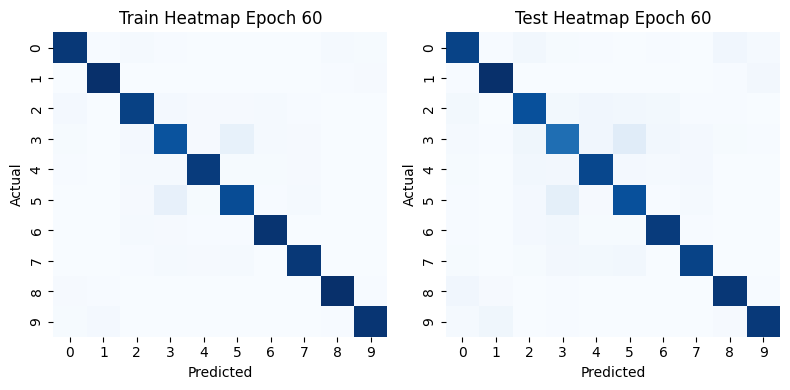

<Figure size 1200x600 with 0 Axes>

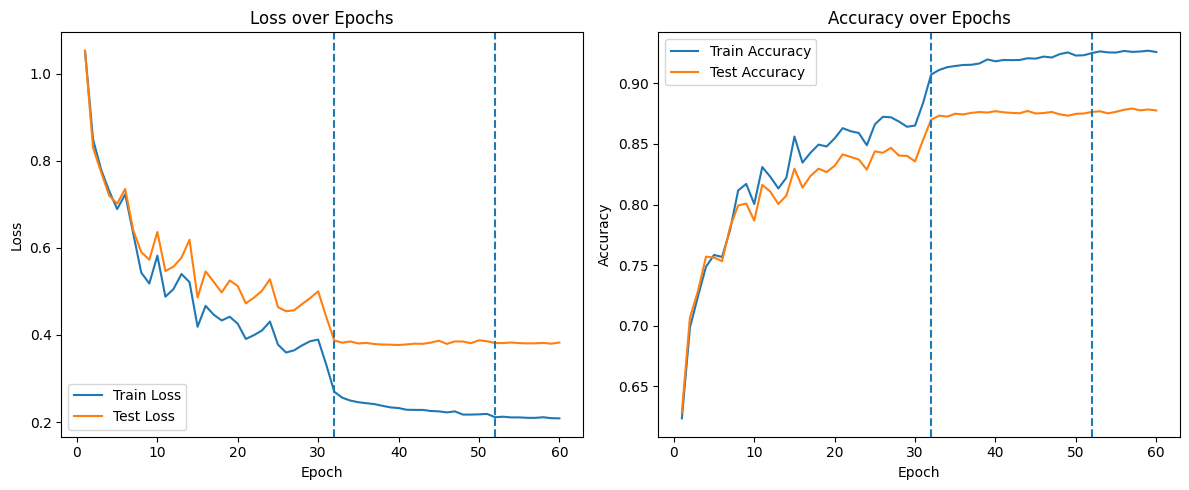

In [6]:
trainf32(model10_0,"model_weights/model10_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model10_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model10_1)
describe(model10_1)

MACs: 5.45 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 0.9234, Train accuracy = 0.6710, Test loss = 0.9056, Test accuracy = 0.6779
Epoch 2/60: Train loss = 0.7926, Train accuracy = 0.7188, Test loss = 0.7957, Test accuracy = 0.7270
Epoch 3/60: Train loss = 0.6757, Train accuracy = 0.7649, Test loss = 0.6616, Test accuracy = 0.7705
Epoch 4/60: Train loss = 0.6453, Train accuracy = 0.7769, Test loss = 0.6638, Test accuracy = 0.7744
Epoch 5/60: Train loss = 0.6772, Train accuracy = 0.7673, Test loss = 0.7015, Test accuracy = 0.7642
Epoch 6/60: Train loss = 0.6048, Train accuracy = 0.7905, Test loss = 0.6302, Test accuracy = 0.7868
Epoch 7/60: Train loss = 0.6304, Train accuracy = 0.7850, Test loss = 0.6760, Test accuracy = 0.7755
Epoch 8/60: Train loss = 0.5236, Train accuracy = 0.8200, Test loss = 0.5751, Test accuracy = 0.8026
Epoch 9/60: Train loss = 0.4875, Train accuracy = 0.8311, Test loss = 0.5315, Test accuracy = 0.8189
Epoch 10/60: Train loss = 0.4571, Train accuracy = 0.8416, Test loss = 0.4985, Test accurac

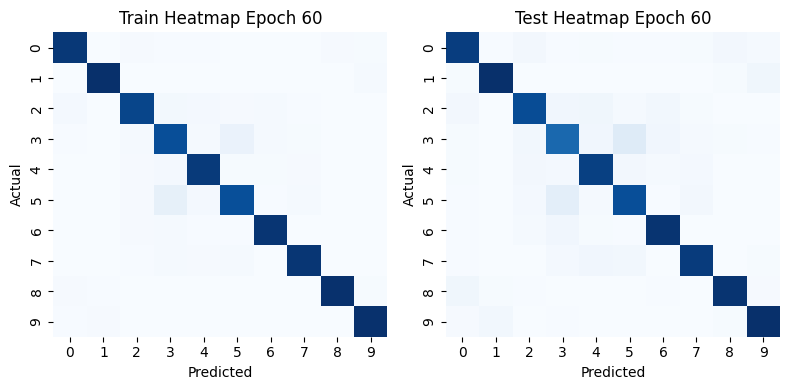

<Figure size 1200x600 with 0 Axes>

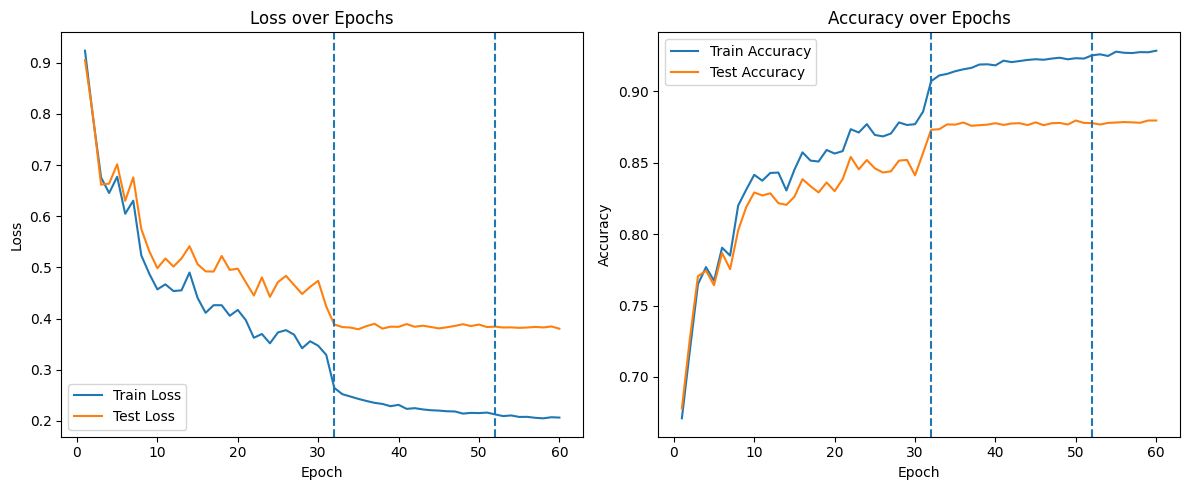

In [8]:
trainf32(model10_1,"model_weights/model10_1.pt",criterion,train_dataset,val_dataset, batch_size=64)